# Compare Calibration Runs

This notebook compares two exported `*_compare_obs_sim.csv` files from the **Run** notebook.

You only need to change filenames in **one place**: the setup cell below.


In [10]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path


## 1) Set the two run files here

Change only these four lines:
- `baseline_run_id`
- `current_run_id`
- `event_start`
- `event_end`

Everything else below updates automatically.


In [11]:
# User inputs: change these only
baseline_run_id = "A12_base"
current_run_id  = "A12_chanK_200"

event_start = "2014-08-12 16:00"
event_end   = "2014-08-13 12:00"

# File paths built automatically from run IDs
baseline_file = Path(f"{baseline_run_id}_compare_obs_sim.csv")
current_file  = Path(f"{current_run_id}_compare_obs_sim.csv")

print("Baseline file exists:", baseline_file.exists(), baseline_file)
print("Current file exists: ", current_file.exists(), current_file)
print("Event window:", event_start, "to", event_end)


Baseline file exists: True A12_base_compare_obs_sim.csv
Current file exists:  True A12_chanK_200_compare_obs_sim.csv
Event window: 2014-08-12 16:00 to 2014-08-13 12:00


## 2) Load the exported comparison files
Each file should already contain:
- `Observed`
- `Simulated`

with datetime as the index.


In [12]:
# Load exported comparison CSVs
base_df = pd.read_csv(baseline_file, index_col=0, parse_dates=True)
curr_df = pd.read_csv(current_file, index_col=0, parse_dates=True)

print("Baseline columns:", list(base_df.columns))
print("Current columns: ", list(curr_df.columns))

display(base_df.head())
display(curr_df.head())


Baseline columns: ['Observed', 'Simulated']
Current columns:  ['Observed', 'Simulated']


,Observed,Simulated
2014-08-01 01:55:00,0.0,0.0000
2014-08-01 07:55:00,0.0,0.0000
2014-08-01 13:55:00,0.0,0.0000
2014-08-01 19:55:00,0.0,0.0001
2014-08-02 01:55:00,0.0,0.0005


,Observed,Simulated
2014-08-01 01:55:00,0.0,0.0
2014-08-01 07:55:00,0.0,0.0
2014-08-01 13:55:00,0.0,0.0
2014-08-01 19:55:00,0.0,0.0
2014-08-02 01:55:00,0.0,0.0


## 3) Clip to the event and align the two runs


In [13]:
# Clip to event window
base_event = base_df.loc[event_start:event_end].copy()
curr_event = curr_df.loc[event_start:event_end].copy()

# Build one comparison table
compare_runs = pd.DataFrame(index=base_event.index)
compare_runs["Observed"] = base_event["Observed"]
compare_runs["Baseline"] = base_event["Simulated"]
compare_runs["Current"]  = curr_event["Simulated"].reindex(compare_runs.index)

# Keep only rows where all series are available
compare_runs = compare_runs.dropna()

# Differences
compare_runs["Difference"] = compare_runs["Current"] - compare_runs["Baseline"]
compare_runs["Abs_Difference"] = compare_runs["Difference"].abs()

display(compare_runs.head(20))
print("Rows compared:", len(compare_runs))


,Observed,Baseline,Current,Difference,Abs_Difference
2014-08-12 18:15:00,0.339802,1.90890,1.35515,-0.55375,0.55375
2014-08-12 18:20:00,11.277166,13.22760,11.56230,-1.66530,1.66530
2014-08-12 18:25:00,27.523930,27.99490,26.12280,-1.87210,1.87210
2014-08-12 18:30:00,34.404912,52.15205,50.62640,-1.52565,1.52565
2014-08-12 18:35:00,40.634608,58.29780,57.60110,-0.69670,0.69670
2014-08-12 18:40:00,44.910445,61.40120,61.03030,-0.37090,0.37090
2014-08-12 18:45:00,37.059612,74.49855,74.31565,-0.18290,0.18290
2014-08-12 18:50:00,28.184655,94.48800,94.35520,-0.13280,0.13280
2014-08-12 18:55:00,18.707966,110.09060,109.97080,-0.11980,0.11980
2014-08-12 19:00:00,13.875232,123.04580,122.97435,-0.07145,0.07145


Rows compared: 23


## 4) Summary metrics


In [14]:
baseline_peak = compare_runs["Baseline"].max()
current_peak = compare_runs["Current"].max()

baseline_peak_time = compare_runs["Baseline"].idxmax()
current_peak_time = compare_runs["Current"].idxmax()

print("Baseline peak:", baseline_peak)
print("Current peak:", current_peak)
print("Baseline peak time:", baseline_peak_time)
print("Current peak time:", current_peak_time)
print("Difference in peak:", current_peak - baseline_peak)
print("Max absolute difference:", compare_runs["Abs_Difference"].max())
print("Mean absolute difference:", compare_runs["Abs_Difference"].mean())
print("Are all simulated values exactly identical?", (compare_runs["Difference"] == 0).all())


Baseline peak: 123.0458
Current peak: 122.97435
Baseline peak time: 2014-08-12 19:00:00
Current peak time: 2014-08-12 19:00:00
Difference in peak: -0.07144999999999868
Max absolute difference: 1.8720999999999997
Mean absolute difference: 0.3525630434782612
Are all simulated values exactly identical? False


## 5) Plot observed, baseline, and current hydrographs


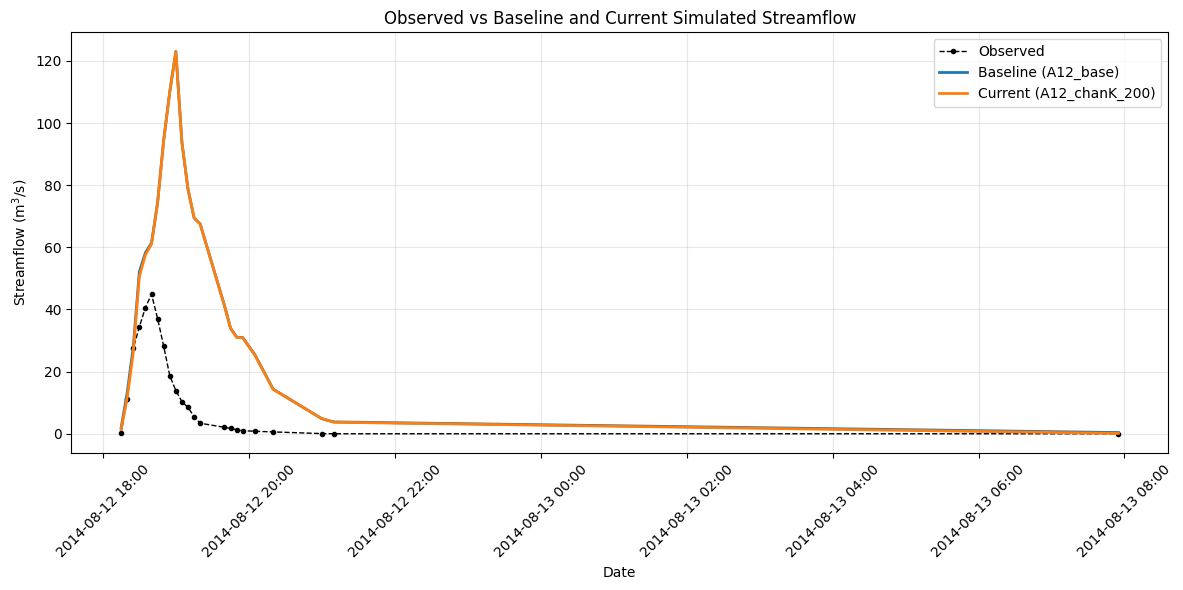

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    compare_runs.index, compare_runs["Observed"],
    label="Observed",
    color="black", linestyle="--", marker="o", markersize=3, linewidth=1
)
ax.plot(
    compare_runs.index, compare_runs["Baseline"],
    label=f"Baseline ({baseline_run_id})",
    linewidth=2
)
ax.plot(
    compare_runs.index, compare_runs["Current"],
    label=f"Current ({current_run_id})",
    linewidth=2
)

ax.set_title("Observed vs Baseline and Current Simulated Streamflow")
ax.set_xlabel("Date")
ax.set_ylabel("Streamflow (m$^3$/s)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
plt.xticks(rotation=45)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 6) Plot current minus baseline difference


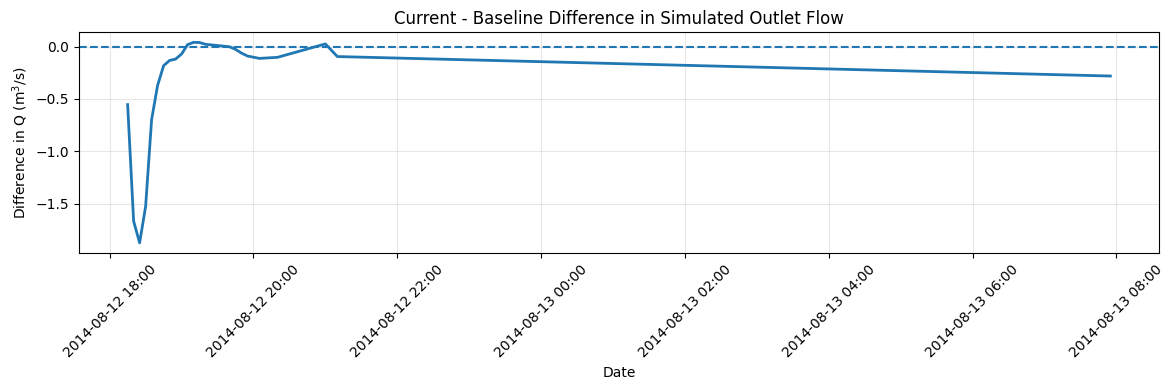

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(compare_runs.index, compare_runs["Difference"], linewidth=2)
ax.axhline(0, linestyle="--")
ax.set_title("Current - Baseline Difference in Simulated Outlet Flow")
ax.set_xlabel("Date")
ax.set_ylabel("Difference in Q (m$^3$/s)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
plt.xticks(rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7) Save the aligned comparison table
This writes one summary CSV for the pair of runs being compared.


In [17]:
comparison_name = f"{baseline_run_id}_vs_{current_run_id}_comparison.csv"
compare_runs.to_csv(comparison_name, index=True)
print("Saved:", comparison_name)


Saved: A12_base_vs_A12_chanK_200_comparison.csv
